# Reproducibility analysis — ReScience-C corpus
## Model: gemini-3.1-pro-preview | Temperature: 0

Single-run profiles from `data/experiments/rescience_c_gemini3_1_pro_T0/`.  
Each profile is scored with `repro_scoring.score_profile`: structural (graph wiring) and content (node-level reproducibility scores), combined as `repro_index = sqrt(structural × content)`.

**Sections**
1. Load & describe
2. Score distributions
3. Structural vs content decomposition
4. Per-paper ranking (top / bottom 15)
5. Year trend
6. Node counts vs reproducibility
7. Structural wiring metrics breakdown
8. Layer-level content scores
9. Metadata richness vs reproducibility

In [11]:
%load_ext autoreload
%autoreload 2

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

from repro_scoring import build_graph, score_profile, wiring_metrics

PROFILE_DIR = Path('data/experiments/rescience_c_gemini3_1_pro_T0')
FIGURE_DIR = Path('figures')
FIGURE_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 3.5,
    'ytick.major.size': 3.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': False,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
})

# Filename pattern: {YEAR}_{NUM}_article_T0_{model}.profile.json
STEM_RE = re.compile(r'^(?P<year>\d{4})_(?P<num>\d+)_article_T0_(?P<model>.+)$')

BLUE   = '#0072B2'
ORANGE = '#D55E00'
GREEN  = '#009E73'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load & score all profiles

The filenames in this directory follow `{YEAR}_{NUM}_article_T0_{model}.profile.json`,  
which differs from the multi-run consistency sweep format, so we use a dedicated loader  
instead of `repro_scoring.load_runs`. Beyond the composite scores we extract:
- Per-layer content scores (`content_source`, `content_process`, `content_sink`)
- All five structural wiring sub-metrics
- Metadata richness signals: repository links, hyperparameter count, software versions

In [12]:
def _layer_mean(items: list[dict]) -> float | None:
    if not items:
        return None
    return sum(int(it.get('reproducibility_score', 0)) for it in items) / len(items) / 100.0


def load_profiles(profile_dir: Path) -> pd.DataFrame:
    rows = []
    for path in sorted(profile_dir.glob('*.profile.json')):
        stem = path.stem.removesuffix('.profile')
        m = STEM_RE.match(stem)
        if m is None:
            continue
        try:
            profile = json.loads(path.read_text(encoding='utf-8'))
        except (json.JSONDecodeError, UnicodeDecodeError):
            continue

        scores = score_profile(profile)
        wm     = wiring_metrics(build_graph(profile))
        meta   = profile.get('metadata', {})

        src_items  = profile.get('nodes_source', [])
        proc_items = profile.get('nodes_process', [])
        snk_items  = profile.get('nodes_sink', [])

        n_open = sum(1 for s in src_items if s.get('availability') == 'open')

        rows.append({
            'paper'        : f"{m['year']}_{m['num']}_article.pdf",
            'year'         : int(m['year']),
            'number'       : int(m['num']),
            'title'        : meta.get('title', ''),
            'n_authors'    : len(meta.get('authors', [])),
            'has_repo'     : bool(meta.get('repository_links')),
            'n_hyperparams': len(meta.get('hyperparameters', [])),
            'n_software'   : len(meta.get('stated_software_versions', {})),
            'has_hardware' : bool(meta.get('hardware_requirements')),
            **scores,
            **wm,
            'content_source' : _layer_mean(src_items),
            'content_process': _layer_mean(proc_items),
            'content_sink'   : _layer_mean(snk_items),
            'algo_clarity_mean': (
                sum(p.get('algorithm_clarity', 0) for p in proc_items) / len(proc_items)
                if proc_items else None
            ),
            'pct_src_open': n_open / len(src_items) if src_items else None,
        })
    return (
        pd.DataFrame(rows)
        .sort_values('repro_index', ascending=False)
        .reset_index(drop=True)
    )


df = load_profiles(PROFILE_DIR)
print(f'Papers loaded: {len(df)}')
df[['paper', 'year', 'repro_index', 'structural', 'content',
    'n_source', 'n_process', 'n_sink']].head(10)

Papers loaded: 213


,paper,year,repro_index,structural,content,n_source,n_process,n_sink
0,2020_27_article.pdf,2020,0.978750,1.000000,0.957951,1.0,18.0,16.0
1,2023_17_article.pdf,2023,0.970567,1.000000,0.942000,2.0,5.0,6.0
2,2023_22_article.pdf,2023,0.954463,1.000000,0.911000,2.0,5.0,6.0
3,2023_43_article.pdf,2023,0.948608,1.000000,0.899857,3.0,5.0,7.0
4,2020_26_article.pdf,2020,0.948046,0.925000,0.971667,1.0,3.0,2.0
5,2023_24_article.pdf,2023,0.945667,1.000000,0.894286,2.0,7.0,6.0
6,2022_25_article.pdf,2022,0.940744,1.000000,0.885000,6.0,4.0,7.0
7,2021_28_article.pdf,2021,0.935136,0.958333,0.912500,3.0,8.0,6.0
8,2022_40_article.pdf,2022,0.932073,0.965714,0.899603,5.0,9.0,7.0
9,2022_37_article.pdf,2022,0.931195,1.000000,0.867125,3.0,10.0,8.0


## Score overview

Descriptive statistics and histograms for the three main scores. The dashed vertical line marks the mean.

       repro_index  structural  content
count      213.000     213.000  213.000
mean         0.762       0.864    0.685
std          0.093       0.139    0.124
min          0.361       0.253    0.130
25%          0.700       0.794    0.605
50%          0.754       0.897    0.672
75%          0.825       1.000    0.772
max          0.979       1.000    0.972


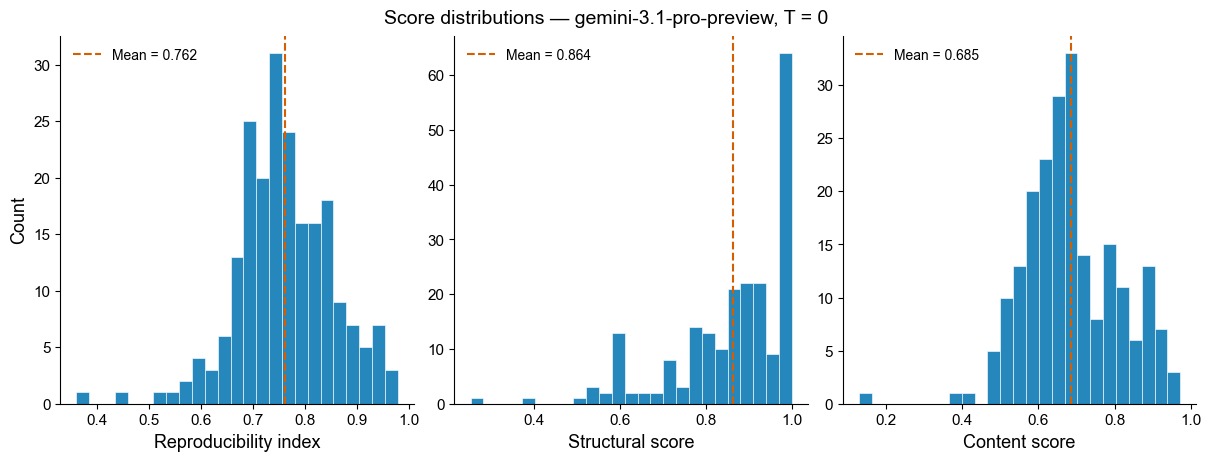

In [13]:
print(df[['repro_index', 'structural', 'content']].describe().round(3))

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), constrained_layout=True)
metrics = [
    ('repro_index', 'Reproducibility index'),
    ('structural',  'Structural score'),
    ('content',     'Content score'),
]
for ax, (col, label) in zip(axes, metrics):
    ax.hist(df[col].dropna(), bins=25, color=BLUE, edgecolor='white',
            linewidth=0.5, alpha=0.85)
    mean_val = df[col].mean()
    ax.axvline(mean_val, color=ORANGE, linewidth=1.5, linestyle='--',
               label=f'Mean = {mean_val:.3f}')
    ax.set_xlabel(label)
    if ax is axes[0]:
        ax.set_ylabel('Count')
    ax.legend(fontsize=10)

fig.suptitle('Score distributions — gemini-3.1-pro-preview, T = 0', fontsize=14)
fig.savefig(FIGURE_DIR / 'gemini3_1_pro_T0_score_distribution.pdf')
fig.savefig(FIGURE_DIR / 'gemini3_1_pro_T0_score_distribution.png')
plt.show()

## Structural vs content decomposition

Each dot is one paper. Colour encodes `repro_index = sqrt(structural × content)`.  
Points above the diagonal have stronger content than structural score; below means the opposite.  
Most papers cluster well below the diagonal — structural wiring is the primary bottleneck.

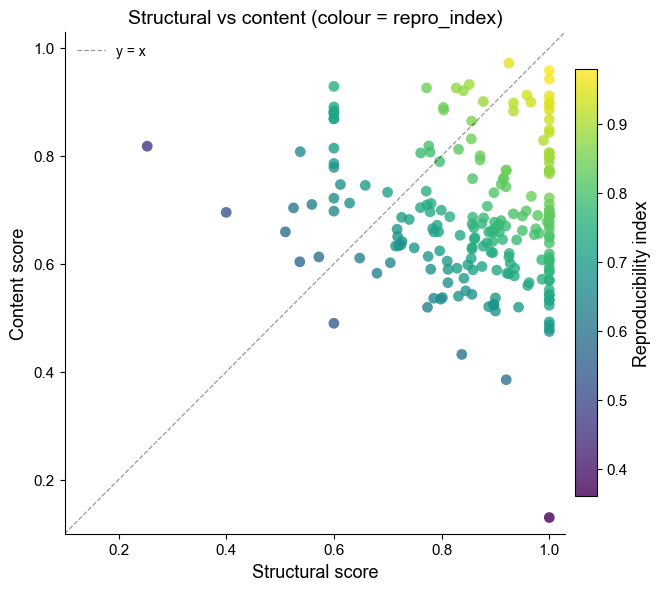

In [ ]:
# fig, ax = plt.subplots(figsize=(6.5, 5.8), constrained_layout=True)
fig, ax = plt.subplots(figsize=(6.5, 4.6), constrained_layout=True)

norm = Normalize(vmin=df['repro_index'].min(), vmax=df['repro_index'].max())
sc = ax.scatter(
    df['structural'], df['content'],
    c=df['repro_index'], cmap='viridis', norm=norm,
    s=60, alpha=0.8, edgecolors='none',
)

lo = min(df['structural'].min(), df['content'].min()) - 0.03
hi = max(df['structural'].max(), df['content'].max()) + 0.03
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.9, alpha=0.4, label='y = x')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)

ax.set_xlabel('Structural score')
ax.set_ylabel('Content score')
ax.set_title('Structural vs content (colour = repro_index)')
ax.legend(fontsize=10)
fig.colorbar(sc, ax=ax, label='Reproducibility index', shrink=0.85, pad=0.02)

fig.savefig(FIGURE_DIR / 'gemini3_1_pro_T0_structural_vs_content.pdf')
fig.savefig(FIGURE_DIR / 'gemini3_1_pro_T0_structural_vs_content.png')
plt.show()

## Per-paper ranking

Top and bottom 15 papers by `repro_index`. Blue bars are above the corpus median; orange bars are below.

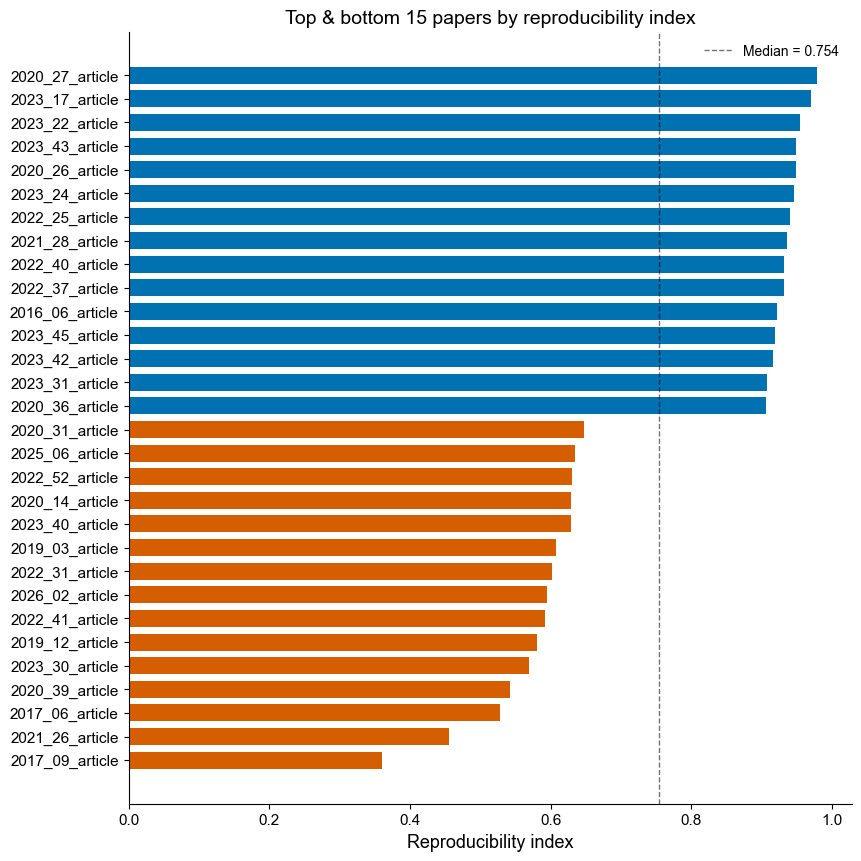

Full ranking:
                   paper  year  repro_index  structural   content
0    2020_27_article.pdf  2020     0.978750    1.000000  0.957951
1    2023_17_article.pdf  2023     0.970567    1.000000  0.942000
2    2023_22_article.pdf  2023     0.954463    1.000000  0.911000
3    2023_43_article.pdf  2023     0.948608    1.000000  0.899857
4    2020_26_article.pdf  2020     0.948046    0.925000  0.971667
5    2023_24_article.pdf  2023     0.945667    1.000000  0.894286
6    2022_25_article.pdf  2022     0.940744    1.000000  0.885000
7    2021_28_article.pdf  2021     0.935136    0.958333  0.912500
8    2022_40_article.pdf  2022     0.932073    0.965714  0.899603
9    2022_37_article.pdf  2022     0.931195    1.000000  0.867125
10   2016_06_article.pdf  2016     0.921005    1.000000  0.848250
11   2023_45_article.pdf  2023     0.918267    1.000000  0.843214
12   2023_42_article.pdf  2023     0.915496    0.933482  0.897857
13   2023_31_article.pdf  2023     0.907817    0.933482  0.882

In [15]:
N = 15
top   = df.head(N).copy()
bot   = df.tail(N).copy()
combo = (
    pd.concat([top, bot])
    .drop_duplicates('paper')
    .sort_values('repro_index')
)
combo['label'] = combo['paper'].str.removesuffix('.pdf')
median_val = df['repro_index'].median()
bar_colors = [ORANGE if v < median_val else BLUE for v in combo['repro_index']]

fig, ax = plt.subplots(figsize=(8.5, 8.5), constrained_layout=True)
ax.barh(combo['label'], combo['repro_index'], color=bar_colors, height=0.72)
ax.axvline(median_val, color='black', linewidth=1.0, linestyle='--',
           alpha=0.55, label=f'Median = {median_val:.3f}')
ax.set_xlabel('Reproducibility index')
ax.set_title(f'Top & bottom {N} papers by reproducibility index')
ax.legend(fontsize=10)

fig.savefig(FIGURE_DIR / 'gemini3_1_pro_T0_paper_ranking.pdf')
fig.savefig(FIGURE_DIR / 'gemini3_1_pro_T0_paper_ranking.png')
plt.show()

print('Full ranking:')
print(
    df[['paper', 'year', 'repro_index', 'structural', 'content']]
    .to_string(index=True)
)

## Year trend

Box plots of `repro_index` by publication year, with the mean overlaid as a line.  
Shows whether later ReScience-C publications are more reproducible according to the model.

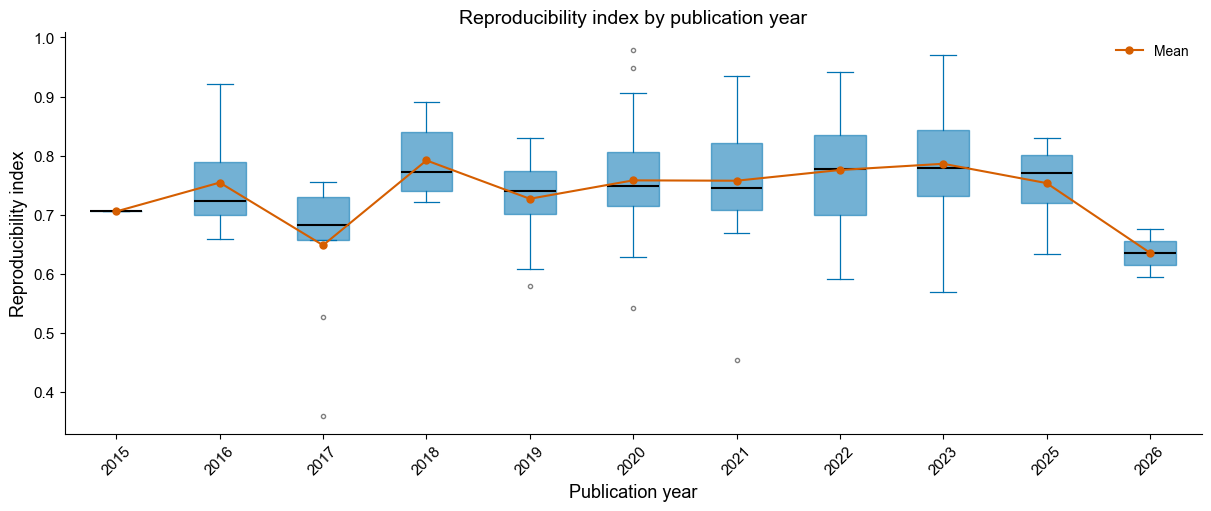

Papers per year:
year
2015     1
2016     7
2017     9
2018     7
2019    10
2020    38
2021    32
2022    53
2023    48
2025     6
2026     2


In [16]:
years = sorted(df['year'].unique())
year_data = [df[df['year'] == y]['repro_index'].values for y in years]

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
bp = ax.boxplot(
    year_data, positions=range(len(years)),
    patch_artist=True, showfliers=True,
    medianprops={'color': 'black', 'linewidth': 1.5},
    boxprops={'facecolor': BLUE, 'alpha': 0.55, 'edgecolor': BLUE},
    whiskerprops={'color': BLUE, 'linewidth': 0.9},
    capprops={'color': BLUE, 'linewidth': 0.9},
    flierprops={'marker': 'o', 'markersize': 3, 'color': BLUE, 'alpha': 0.5},
)
means = [np.mean(d) for d in year_data]
ax.plot(range(len(years)), means, 'o-', color=ORANGE, markersize=5,
        linewidth=1.5, label='Mean', zorder=3)

ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, rotation=45)
ax.set_xlabel('Publication year')
ax.set_ylabel('Reproducibility index')
ax.set_title('Reproducibility index by publication year')
ax.legend(fontsize=10)

fig.savefig(FIGURE_DIR / 'gemini3_1_pro_T0_repro_by_year.pdf')
fig.savefig(FIGURE_DIR / 'gemini3_1_pro_T0_repro_by_year.png')
plt.show()

print('Papers per year:')
print(df.groupby('year').size().rename('n').to_string())

## Node counts vs reproducibility

Scatter of each node-count column against `repro_index`. Pearson *r* in each title.  
A positive correlation would indicate that richer workflow graphs tend to be more reproducible.

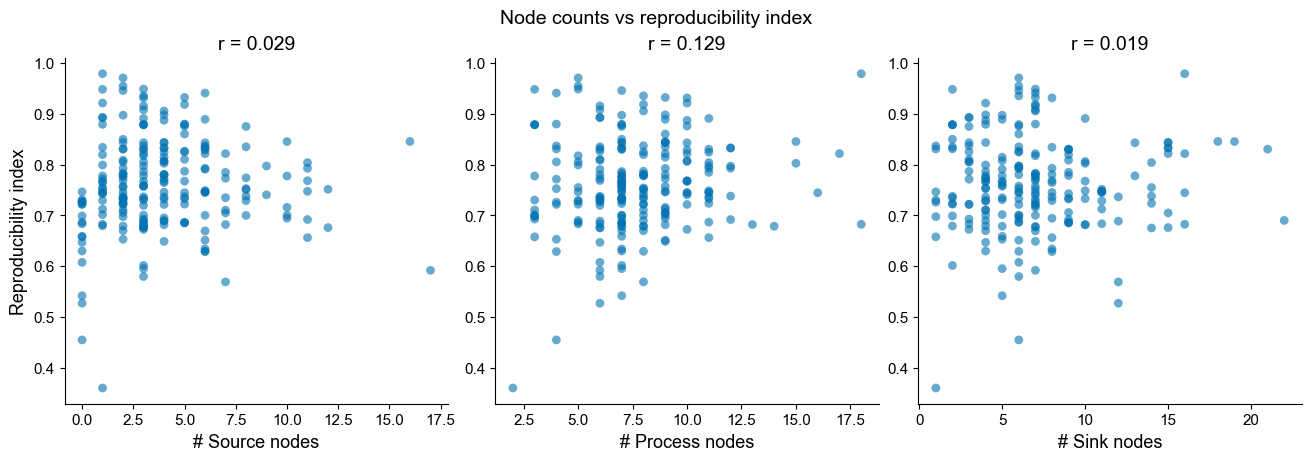

       n_source  n_process  n_sink
count     213.0      213.0   213.0
mean        3.9        7.7     6.9
std         3.0        2.8     4.0
min         0.0        2.0     1.0
25%         2.0        6.0     4.0
50%         3.0        7.0     6.0
75%         5.0        9.0     9.0
max        17.0       18.0    22.0


In [17]:
node_cols = [
    ('n_source',  '# Source nodes'),
    ('n_process', '# Process nodes'),
    ('n_sink',    '# Sink nodes'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), constrained_layout=True)
for ax, (col, label) in zip(axes, node_cols):
    ax.scatter(df[col], df['repro_index'], color=BLUE, alpha=0.60, s=40, edgecolors='none')
    r = df[[col, 'repro_index']].corr().iloc[0, 1]
    ax.set_xlabel(label)
    if ax is axes[0]:
        ax.set_ylabel('Reproducibility index')
    ax.set_title(f'r = {r:.3f}')

fig.suptitle('Node counts vs reproducibility index', fontsize=14)
fig.savefig(FIGURE_DIR / 'gemini3_1_pro_T0_node_counts_vs_repro.pdf')
fig.savefig(FIGURE_DIR / 'gemini3_1_pro_T0_node_counts_vs_repro.png')
plt.show()

print(df[['n_source', 'n_process', 'n_sink']].describe().round(1))

## Structural wiring metrics breakdown

The structural score is a weighted sum of five wiring metrics (see `repro_scoring.STRUCT_W`).  
This bar chart shows the mean ± std of each metric across all papers, revealing which  
aspect of the workflow graph is most and least complete on average.

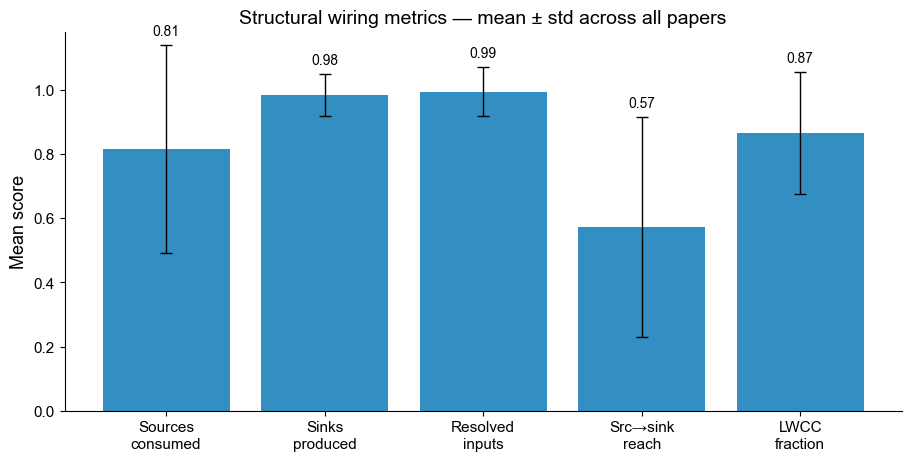

       sources_consumed_ratio  sinks_produced_ratio  resolved_input_ratio  \
count                 213.000               213.000               213.000   
mean                    0.815                 0.983                 0.993   
std                     0.324                 0.067                 0.076   
min                     0.000                 0.455                 0.000   
25%                     0.750                 1.000                 1.000   
50%                     1.000                 1.000                 1.000   
75%                     1.000                 1.000                 1.000   
max                     1.000                 1.000                 1.000   

       source_to_sink_reachability  lwcc_fraction  
count                      213.000        213.000  
mean                         0.572          0.865  
std                          0.343          0.190  
min                          0.000          0.114  
25%                          0.300          0.

In [18]:
wiring_cols = [
    'sources_consumed_ratio',
    'sinks_produced_ratio',
    'resolved_input_ratio',
    'source_to_sink_reachability',
    'lwcc_fraction',
]
wiring_labels = [
    'Sources\nconsumed',
    'Sinks\nproduced',
    'Resolved\ninputs',
    'Src\u2192sink\nreach',
    'LWCC\nfraction',
]
means_wm = df[wiring_cols].mean()
stds_wm  = df[wiring_cols].std()

fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
x = np.arange(len(wiring_cols))
ax.bar(
    x, means_wm, yerr=stds_wm, color=BLUE, alpha=0.80, capsize=4,
    error_kw={'linewidth': 1.0, 'ecolor': 'black', 'capthick': 1.0},
)
for i, (v, s) in enumerate(zip(means_wm, stds_wm)):
    ax.text(i, v + s + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(wiring_labels)
ax.set_ylabel('Mean score')
ax.set_ylim(0, 1.18)
ax.set_title('Structural wiring metrics — mean \u00b1 std across all papers')

fig.savefig(FIGURE_DIR / 'gemini3_1_pro_T0_wiring_metrics.pdf')
fig.savefig(FIGURE_DIR / 'gemini3_1_pro_T0_wiring_metrics.png')
plt.show()

print(df[wiring_cols].describe().round(3))

## Layer-level content scores

Content score is a weighted average of per-layer means (source 0.30, process 0.40, sink 0.30).  
These box plots show the raw per-layer distributions before weighting, exposing which research  
component the model finds most and least reproducible.

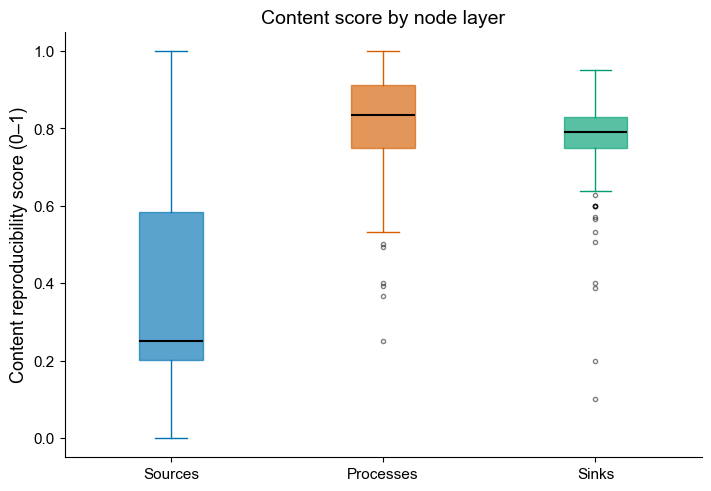

       content_source  content_process  content_sink
count         195.000          213.000       213.000
mean            0.393            0.812         0.775
std             0.323            0.130         0.103
min             0.000            0.250         0.100
25%             0.202            0.750         0.750
50%             0.250            0.833         0.792
75%             0.583            0.911         0.830
max             1.000            1.000         0.950


In [19]:
layer_cols   = ['content_source', 'content_process', 'content_sink']
layer_labels = ['Sources', 'Processes', 'Sinks']
layer_colors = [BLUE, ORANGE, GREEN]
layer_data   = [df[c].dropna().values for c in layer_cols]

fig, ax = plt.subplots(figsize=(7, 4.8), constrained_layout=True)
bp = ax.boxplot(
    layer_data, patch_artist=True, showfliers=True,
    medianprops={'color': 'black', 'linewidth': 1.5},
)
for patch, wh1, wh2, cap1, cap2, flier, color in zip(
    bp['boxes'],
    bp['whiskers'][::2], bp['whiskers'][1::2],
    bp['caps'][::2],     bp['caps'][1::2],
    bp['fliers'],
    layer_colors,
):
    patch.set(facecolor=color, alpha=0.65, edgecolor=color)
    for elem in (wh1, wh2, cap1, cap2):
        elem.set_color(color)
    flier.set(marker='o', markersize=3, color=color, alpha=0.5)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(layer_labels)
ax.set_ylabel('Content reproducibility score (0\u20131)')
ax.set_title('Content score by node layer')

fig.savefig(FIGURE_DIR / 'gemini3_1_pro_T0_layer_content.pdf')
fig.savefig(FIGURE_DIR / 'gemini3_1_pro_T0_layer_content.png')
plt.show()

print(df[layer_cols].describe().round(3))

## Metadata richness vs reproducibility

**Left**: Does reporting a code repository correlate with a higher `repro_index`?  
**Right**: Does the number of explicitly reported hyperparameters correlate with reproducibility?

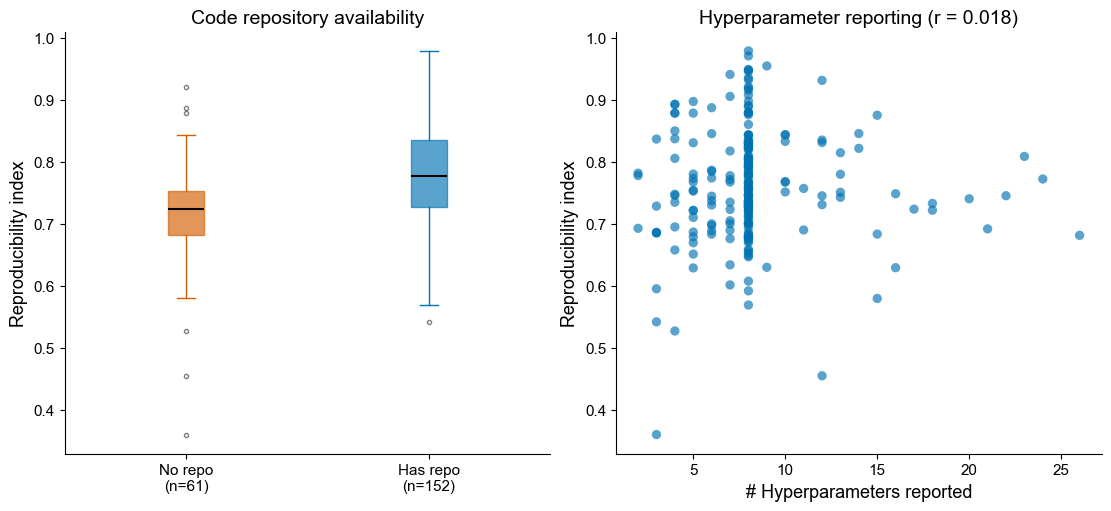

          count   mean  median    std
has_repo                             
False        61  0.714   0.724  0.091
True        152  0.781   0.778  0.086


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)

# Panel A — repository availability
ax = axes[0]
n_no  = (~df['has_repo']).sum()
n_yes = df['has_repo'].sum()
groups = [
    df[~df['has_repo']]['repro_index'].values,
    df[ df['has_repo']]['repro_index'].values,
]
bp = ax.boxplot(
    groups, patch_artist=True, showfliers=True,
    medianprops={'color': 'black', 'linewidth': 1.5},
)
for patch, color in zip(bp['boxes'], [ORANGE, BLUE]):
    patch.set(facecolor=color, alpha=0.65, edgecolor=color)
for wh, color in zip(bp['whiskers'], [ORANGE, ORANGE, BLUE, BLUE]):
    wh.set_color(color)
for cap, color in zip(bp['caps'], [ORANGE, ORANGE, BLUE, BLUE]):
    cap.set_color(color)
for flier, color in zip(bp['fliers'], [ORANGE, BLUE]):
    flier.set(marker='o', markersize=3, color=color, alpha=0.5)
ax.set_xticks([1, 2])
ax.set_xticklabels([f'No repo\n(n={n_no})', f'Has repo\n(n={n_yes})'])
ax.set_ylabel('Reproducibility index')
ax.set_title('Code repository availability')

# Panel B — hyperparameter count
ax = axes[1]
ax.scatter(df['n_hyperparams'], df['repro_index'], color=BLUE,
           alpha=0.65, s=45, edgecolors='none')
r = df[['n_hyperparams', 'repro_index']].corr().iloc[0, 1]
ax.set_xlabel('# Hyperparameters reported')
ax.set_ylabel('Reproducibility index')
ax.set_title(f'Hyperparameter reporting (r = {r:.3f})')

fig.savefig(FIGURE_DIR / 'gemini3_1_pro_T0_metadata_richness.pdf')
fig.savefig(FIGURE_DIR / 'gemini3_1_pro_T0_metadata_richness.png')
plt.show()

# Summary table
print(
    df.groupby('has_repo')['repro_index']
    .agg(['count', 'mean', 'median', 'std'])
    .round(3)
)